# 15 — Equity derivatives: vega and curvature

Calculate vega and curvature separately for the equity derivatives portfolio.

Vanilla, index and barrier options create nonlinear equity exposure. Vega measures volatility risk. Curvature measures loss under larger regulatory up and down shocks after removing the delta contribution.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from IPython.display import display
from frtb_engine.notebook_tools import (
    INR_CRORE, bar_crore, bar_inr, configure_notebooks, crore_table,
    draw_capital_map, draw_flow, heatmap, percent_columns,
)

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
print(f'Calculation run used in this notebook: {RUN_ID}')

Calculation run used in this notebook: SA_20260901T122303Z


This is the part of the calculation chain being handled here:

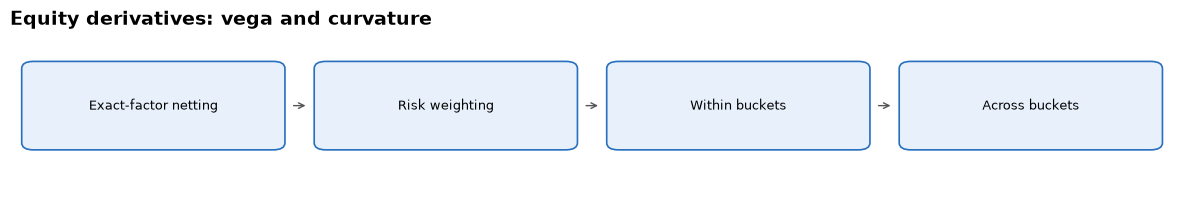

In [2]:
draw_flow(['Exact-factor netting', 'Risk weighting', 'Within buckets', 'Across buckets'],'Equity derivatives: vega and curvature',wrap_after=4)

Price vega uses a one percentage-point volatility bump and is multiplied by current implied volatility for the regulatory sensitivity. Curvature fully reprices under both risk-weight shocks. It is not simply gamma because the regulatory calculation removes the delta effect and aggregates both directions separately.

$$s^{vega}=\frac{V(\sigma+0.01)-V(\sigma)}{0.01}\times\sigma$$

$$CVR^{up}=-[V(x+RW)-V(x)-RW\times\Delta]$$

$$CVR^{down}=-[V(x-RW)-V(x)+RW\times\Delta]$$

In [3]:
from frtb_engine.parameters import risk_weight
vega=pd.read_csv(RUN/'04_vega_trade_level.csv')
curvature=pd.read_csv(RUN/'05_curvature_trade_level.csv')
desk_vega=vega[vega.desk=='Equity'].copy()
desk_curvature=curvature[curvature.desk=='Equity'].copy()
desk_vega['one_vol_point_change_inr']=desk_vega.shocked_value_inr-desk_vega.base_value_inr
desk_vega['applicable_risk_weight']=desk_vega.apply(lambda row:risk_weight(row.to_dict(),'VEGA'),axis=1)
print('Vega rows')
vega_shown=crore_table(desk_vega[['trade_id','instrument_type','risk_class','risk_factor_id','applicable_risk_weight','one_vol_point_change_inr','raw_sensitivity']],['one_vol_point_change_inr','raw_sensitivity'])
display(percent_columns(vega_shown,['applicable_risk_weight']))
print('Curvature rows')
columns=['trade_id','instrument_type','risk_class','risk_factor_id','shock_size','base_value_inr',
         'shocked_value_inr','down_value_inr','curvature_up','curvature_down','raw_sensitivity']
display(percent_columns(crore_table(desk_curvature[columns],['base_value_inr','shocked_value_inr','down_value_inr','curvature_up','curvature_down','raw_sensitivity']),['shock_size']))

Vega rows


,trade_id,instrument_type,risk_class,risk_factor_id,Applicable Risk Weight (%),One Vol Point Change (INR crore),Raw Sensitivity (INR crore per unit change)
7,E03,EQUITY_OPTION,EQUITY,RELIANCE_VOL_0.5Y,77.7800,0.0410,1.1478
8,E09,EQUITY_OPTION,EQUITY,NIFTY50_VOL_0.5Y,77.7800,-0.0654,-1.3088
9,E10,BARRIER_OPTION,EQUITY,NIFTY50_VOL_1.0Y,77.7800,-0.0474,-0.9485


Curvature rows


,trade_id,instrument_type,risk_class,risk_factor_id,Shock Size (%),Base Value (INR crore),Shocked Value (INR crore),Down Value (INR crore),Curvature Up (INR crore),Curvature Down (INR crore),Raw Sensitivity (INR crore per unit change)
9,E03,EQUITY_OPTION,GIRR,INR_CURVE,1.7000,1.3522,1.4161,1.2899,-0.0008,-0.0008,0.0000
10,E03,EQUITY_OPTION,EQUITY,RELIANCE,45.0000,1.3522,7.0997,0.0012,-1.7345,-2.6619,0.0000
11,E09,EQUITY_OPTION,GIRR,INR_CURVE,1.7000,-1.9304,-2.0510,-1.8135,0.0018,0.0019,0.0019
12,E09,EQUITY_OPTION,EQUITY,NIFTY50,25.0000,-1.9304,-7.2426,-0.0492,1.2560,2.1751,2.1751
13,E10,BARRIER_OPTION,GIRR,INR_CURVE,1.7000,0.4535,0.4562,0.4476,0.0016,0.0015,0.0016
14,E10,BARRIER_OPTION,EQUITY,NIFTY50,25.0000,0.4535,0.0000,0.1652,0.2194,0.5223,0.5223


The visual below uses the calculated rows shown above.

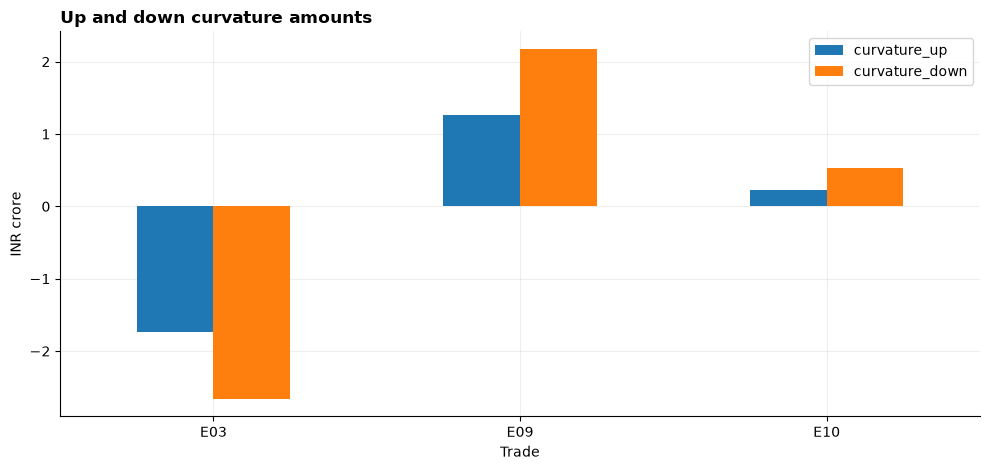

In [4]:
plot_rows=desk_curvature.groupby('trade_id')[['curvature_up','curvature_down']].sum()/INR_CRORE
ax=plot_rows.plot(kind='bar'); ax.set_title('Up and down curvature amounts',loc='left',weight='bold')
ax.set_ylabel('INR crore'); ax.set_xlabel('Trade'); ax.tick_params(axis='x',rotation=0)
plt.tight_layout(); plt.show()

Vega captures volatility risk; curvature captures nonlinear loss missed by a linear delta approximation.